# Foraging — entrega

Notebook de la entrega: corre los experimentos en Foraging (entorno secuencial cooperativo basado en `lbforaging`) con IQL y JAL-AM (implementaciones del equipo, en `agents/`). Persiste `history` dicts y agentes entrenados en `data/foraging/`, guarda figuras en `images/foraging/`, y registra el progreso en `logs/foraging/Foraging.log`.

Las gráficas usan los helpers de `utils.plots` específicos para Foraging (`plot_foraging_rewards`, `plot_foraging_policy_stability`, `plot_foraging_states_qtable`, `plot_foraging_coordination`). Configuración: `SEED=1`, `ITERATIONS=200`, `EPISODES_PER_ITER=1000` (un total de 200 000 episodios por enfrentamiento).

Se evalúan tres enfrentamientos:

- IQL vs IQL — aprendizaje independiente, cada agente trata al otro como parte del entorno
- JAL-AM vs JAL-AM — joint action learning con modelado del otro agente
- IQL vs JAL-AM — comparación directa entre aprendizaje independiente y con modelado

## Setup

In [53]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

from dataclasses import replace
from itertools import combinations
import pickle
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

from games.foraging import Foraging
from agents.iql_agent import IQLAgent, IQLAgentConfig
from agents.jal_am_agent import JALAMAgent, JALAMAgentConfig

from utils.logger import get_logger
from utils.storage import load_agents, data_dir
from utils.plots import (
    plot_foraging_rewards,
    plot_foraging_policy_stability,
    plot_foraging_states_qtable,
    plot_foraging_coordination,
)
from utils import experiments as exp

log = get_logger(notebook_name='Foraging2', game='foraging')

# Configuración del entorno y entrenamiento.
GAME_NAME = 'Foraging-8x8-2p-1f-v3'
SEED = 1
MAX_EPISODE_STEPS = 200
EPISODES_PER_ITER = 1000
ITERATIONS = 200
MAX_ITER = None

# Si FORCE_RUN=False, se reutiliza el pickle si existe. Cambiar a True para regenerar.
FORCE_RUN = True

IQL_CONFIG = IQLAgentConfig(alpha=0.1, gamma=0.99, min_epsilon=0.01, max_t=200000, seed=SEED)
JALAM_CONFIG = JALAMAgentConfig(alpha=0.1, gamma=0.99, min_epsilon=0.01, max_t=200000, seed=SEED)

SCENARIOS = {
    'IQL vs IQL': [(IQLAgent, IQL_CONFIG), (IQLAgent, IQL_CONFIG)],
    'JAL-AM vs JAL-AM': [(JALAMAgent, JALAM_CONFIG), (JALAMAgent, JALAM_CONFIG)],
    'IQL vs JAL-AM': [(IQLAgent, IQL_CONFIG), (JALAMAgent, JALAM_CONFIG)],
}

log.info('Setup Foraging2 listo')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-05-24 18:51:06 | INFO    | Setup Foraging2 listo


## Helpers de entrenamiento

El loop registra métricas por iteración para que cada enfrentamiento tenga sus propias figuras: reward promedio, curva de aprendizaje, estabilidad de política, estados visitados, tamaño de Q-table y coordinación entre agentes.


In [54]:
def scenario_slug(name):
    slug = name.lower().replace('jal-am', 'jalam')
    return re.sub(r'[^a-z0-9]+', '_', slug).strip('_')


def make_game(seed=SEED):
    return Foraging(config=GAME_NAME, seed=seed, max_episode_steps=MAX_EPISODE_STEPS)


def make_agents(game, scenario_name, seed=SEED):
    specs = SCENARIOS[scenario_name]
    agents = {}
    for idx, agent_name in enumerate(game.agents):
        AgentClass, base_config = specs[idx]
        cfg = replace(base_config, seed=seed + idx)
        agents[agent_name] = AgentClass(game=game, agent=agent_name, config=cfg)
    return agents


def agent_kind(agent):
    if isinstance(agent, IQLAgent):
        return 'IQL'
    if isinstance(agent, JALAMAgent):
        return 'JAL-AM'
    return type(agent).__name__


def q_table_size(agent):
    return len(getattr(agent, 'q', {}))


def policy_snapshot(game, agents):
    # Comparamos políticas greedy en el estado inicial, sin mutar las Q-tables.
    game.reset()
    return {agent_name: np.asarray(agent.policy(), dtype=float) for agent_name, agent in agents.items()}


def policy_delta(previous, current):
    if previous is None:
        return {agent: 0.0 for agent in current}
    return {agent: float(np.linalg.norm(current[agent] - previous[agent])) for agent in current}


def average_pairwise_distance(game):
    positions = [player.position for player in game._env.players]
    if len(positions) < 2:
        return 0.0
    distances = []
    for p1, p2 in combinations(positions, 2):
        distances.append(abs(p1[0] - p2[0]) + abs(p1[1] - p2[1]))
    return float(np.mean(distances))


def joint_load_rate(game, actions):
    load_count = sum(1 for action in actions.values() if game.action_set[action] == 'LOAD')
    return 1.0 if load_count >= 2 else 0.0

In [55]:
def play_episode(game, agents, render=False):
    game.reset()
    for agent in game.agents:
        agents[agent].reset()

    cum_rewards = {agent: 0.0 for agent in game.agents}
    pairwise_distances = []
    joint_load_rates = []
    step_count = 0

    def show_game():
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        game.render_board(ax=ax)
        plt.show()
        time.sleep(0.05)

    if render:
        show_game()

    while not game.done():
        step_count += 1
        actions = {agent: agents[agent].action() for agent in game.agents}
        game.step(actions)

        pairwise_distances.append(average_pairwise_distance(game))
        joint_load_rates.append(joint_load_rate(game, actions))

        for agent in game.agents:
            cum_rewards[agent] += game.reward(agent)

        if render:
            show_game()

        for agent in game.agents:
            agents[agent].update()

    return {
        'rewards': cum_rewards,
        'avg_pairwise_distance': float(np.mean(pairwise_distances)) if pairwise_distances else 0.0,
        'joint_load_rate': float(np.mean(joint_load_rates)) if joint_load_rates else 0.0,
        'steps': step_count,
    }


def run_iteration(game, agents, episodes):
    sum_rewards = {agent: 0.0 for agent in game.agents}
    pairwise_distances = []
    joint_load_rates = []
    steps = []

    for _ in range(episodes):
        episode = play_episode(game, agents)
        for agent in game.agents:
            sum_rewards[agent] += episode['rewards'][agent]
        pairwise_distances.append(episode['avg_pairwise_distance'])
        joint_load_rates.append(episode['joint_load_rate'])
        steps.append(episode['steps'])

    return {
        'avg_rewards': {agent: sum_rewards[agent] / episodes for agent in game.agents},
        'avg_pairwise_distance': float(np.mean(pairwise_distances)),
        'joint_load_rate': float(np.mean(joint_load_rates)),
        'avg_steps': float(np.mean(steps)),
    }

In [56]:
def train_scenario(scenario_name, seed=SEED, episodes_per_iter=EPISODES_PER_ITER, iterations=ITERATIONS):
    game = make_game(seed)
    agents = make_agents(game, scenario_name, seed)
    slug = scenario_slug(scenario_name)

    history = {
        'scenario': scenario_name,
        'game_name': GAME_NAME,
        'seed': seed,
        'episodes_per_iter': episodes_per_iter,
        'iterations': iterations,
        'max_episode_steps': MAX_EPISODE_STEPS,
        'agent_types': {agent: agent_kind(agents[agent]) for agent in game.agents},
        'avg_rewards': {agent: [] for agent in game.agents},
        'mean_reward': [],
        'policy_delta': {agent: [] for agent in game.agents},
        'q_table_size': {agent: [] for agent in game.agents},
        'visited_states': {agent: [] for agent in game.agents},
        'avg_pairwise_distance': [],
        'joint_load_rate': [],
        'avg_steps': [],
    }

    log.info(f'{scenario_name}: inicio {iterations} iter × {episodes_per_iter} episodios')
    previous_policy = None
    log_every = max(1, iterations // 10)

    for iteration in range(1, iterations + 1):
        iteration_metrics = run_iteration(game, agents, episodes_per_iter)

        for agent in game.agents:
            history['avg_rewards'][agent].append(iteration_metrics['avg_rewards'][agent])
            size = q_table_size(agents[agent])
            history['q_table_size'][agent].append(size)
            history['visited_states'][agent].append(size)

        history['mean_reward'].append(float(np.mean(list(iteration_metrics['avg_rewards'].values()))))
        history['avg_pairwise_distance'].append(iteration_metrics['avg_pairwise_distance'])
        history['joint_load_rate'].append(iteration_metrics['joint_load_rate'])
        history['avg_steps'].append(iteration_metrics['avg_steps'])

        current_policy = policy_snapshot(game, agents)
        deltas = policy_delta(previous_policy, current_policy)
        previous_policy = current_policy
        for agent in game.agents:
            history['policy_delta'][agent].append(deltas[agent])

        if iteration == 1 or iteration % log_every == 0 or iteration == iterations:
            reward_msg = {a: round(history['avg_rewards'][a][-1], 4) for a in game.agents}
            q_msg = {a: history['q_table_size'][a][-1] for a in game.agents}
            log.info(f'{scenario_name}: iter {iteration}/{iterations} reward={reward_msg} |Q|={q_msg}')

    for agent in game.agents:
        agents[agent].learn = False

    exp.save_agents(agents, name=f'foraging_{slug}', game='foraging')
    log.info(f'{scenario_name}: agentes guardados como foraging_{slug}')
    return history


def run_or_load_scenario(scenario_name):
    slug = scenario_slug(scenario_name)
    cache_name = f'foraging_history_{slug}'
    cache_force = FORCE_RUN
    if not FORCE_RUN:
        cache_path = data_dir('foraging') / f'{cache_name}.pkl'
        if cache_path.exists():
            with open(cache_path, 'rb') as f:
                cached_history = pickle.load(f)
            cache_force = not (
                cached_history.get('iterations') == ITERATIONS
                and cached_history.get('episodes_per_iter') == EPISODES_PER_ITER
                and cached_history.get('game_name') == GAME_NAME
                and cached_history.get('max_episode_steps') == MAX_EPISODE_STEPS
            )
            if cache_force:
                log.info(f'{scenario_name}: cache incompatible con la configuración actual; se reentrena')
        else:
            cache_force = True
    if not cache_force:
        log.info(f'{scenario_name}: reutilizando cache compatible ({ITERATIONS} × {EPISODES_PER_ITER})')
    return exp.cached(
        cache_name,
        lambda: train_scenario(scenario_name),
        force=cache_force,
        game='foraging',
    )


def plot_report_figures(history):
    slug = scenario_slug(history['scenario'])
    title_prefix = f"Foraging: {history['scenario']}"

    plot_foraging_rewards(history, title=f'{title_prefix} — rewards y aprendizaje',
                          save=f'foraging/{slug}_rewards_learning', max_iter=MAX_ITER)
    plt.show()

    plot_foraging_policy_stability(history, title=f'{title_prefix} — estabilidad de políticas',
                                   save=f'foraging/{slug}_policy_stability', max_iter=MAX_ITER)
    plt.show()

    plot_foraging_states_qtable(history, title=f'{title_prefix} — estados y Q-table',
                                save=f'foraging/{slug}_states_qtable', max_iter=MAX_ITER)
    plt.show()

    plot_foraging_coordination(history, title=f'{title_prefix} — coordinación',
                               save=f'foraging/{slug}_coordination', max_iter=MAX_ITER)
    plt.show()

## IQL vs IQL

Ambos agentes aprenden Q-values de forma independiente, tratando al otro agente como parte del entorno. Es el caso base para ver cuánto aprende IQL sin modelar explícitamente acciones conjuntas.


2026-05-24 10:46:38 | INFO    | IQL vs IQL: inicio 200 iter × 1000 episodios
2026-05-24 10:46:42 | INFO    | IQL vs IQL: iter 1/200 reward={'agent_0': 0.2805, 'agent_1': 0.1485} |Q|={'agent_0': 3037, 'agent_1': 3037}
2026-05-24 10:46:59 | INFO    | IQL vs IQL: iter 20/200 reward={'agent_0': 0.9935, 'agent_1': 0.0065} |Q|={'agent_0': 3367, 'agent_1': 3367}
2026-05-24 10:47:11 | INFO    | IQL vs IQL: iter 40/200 reward={'agent_0': 0.988, 'agent_1': 0.012} |Q|={'agent_0': 3367, 'agent_1': 3367}
2026-05-24 10:47:24 | INFO    | IQL vs IQL: iter 60/200 reward={'agent_0': 0.9935, 'agent_1': 0.0055} |Q|={'agent_0': 3367, 'agent_1': 3367}
2026-05-24 10:47:36 | INFO    | IQL vs IQL: iter 80/200 reward={'agent_0': 0.9945, 'agent_1': 0.0055} |Q|={'agent_0': 3367, 'agent_1': 3367}
2026-05-24 10:47:48 | INFO    | IQL vs IQL: iter 100/200 reward={'agent_0': 0.985, 'agent_1': 0.015} |Q|={'agent_0': 3367, 'agent_1': 3367}
2026-05-24 10:48:00 | INFO    | IQL vs IQL: iter 120/200 reward={'agent_0': 0.993

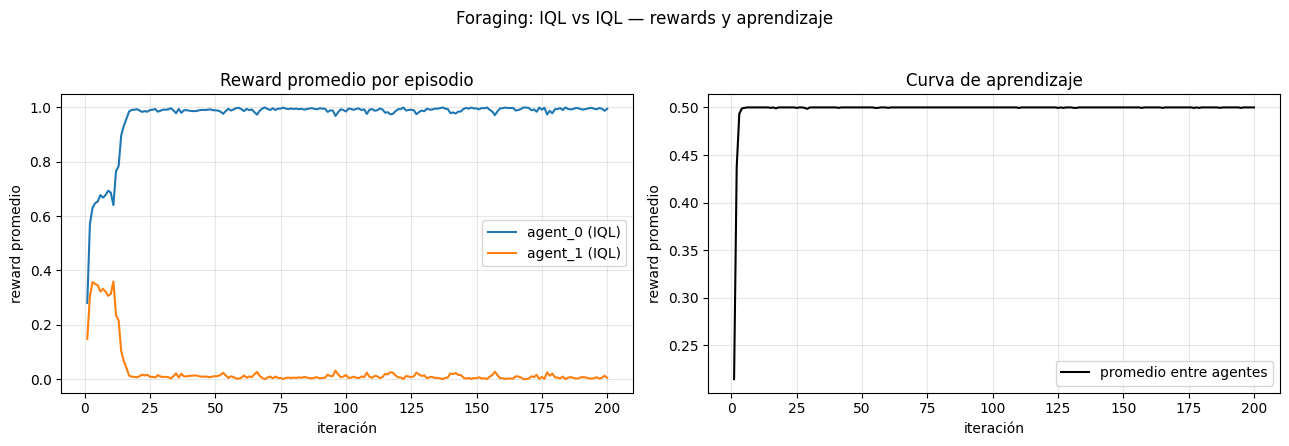

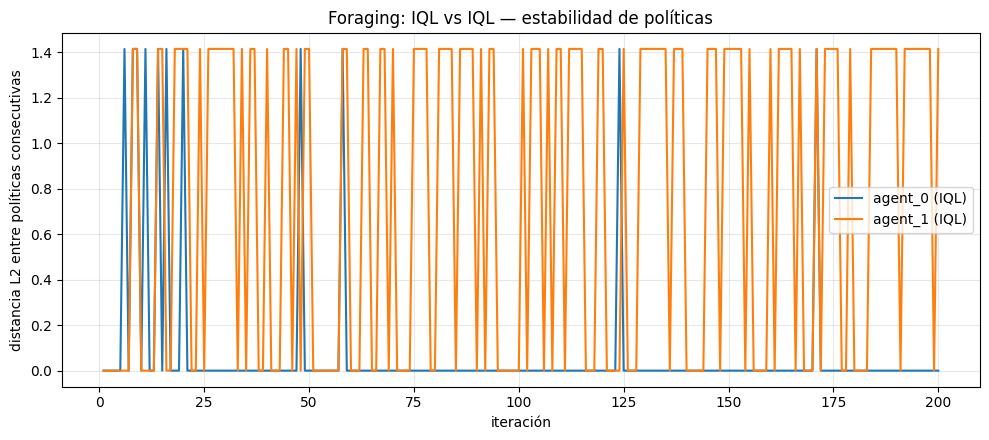

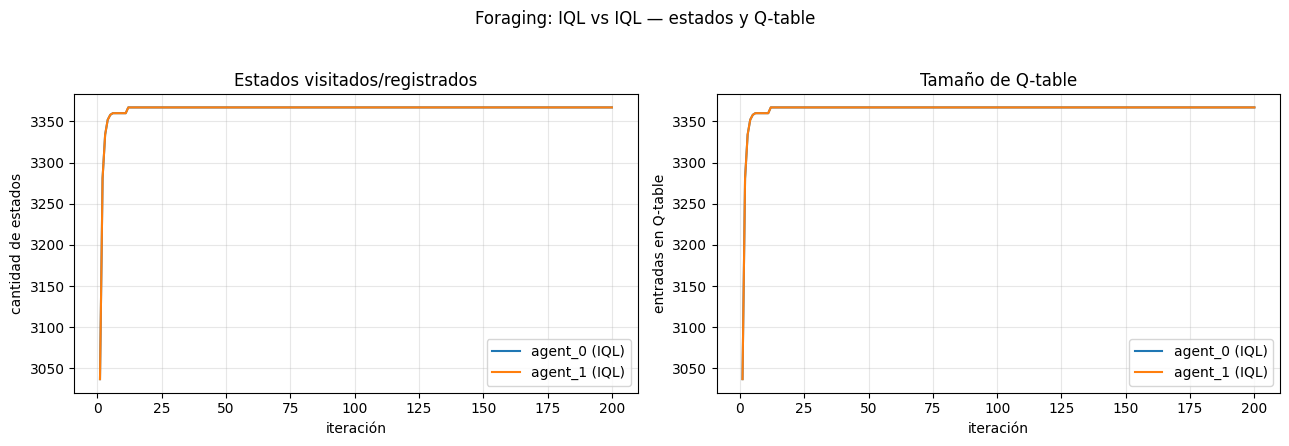

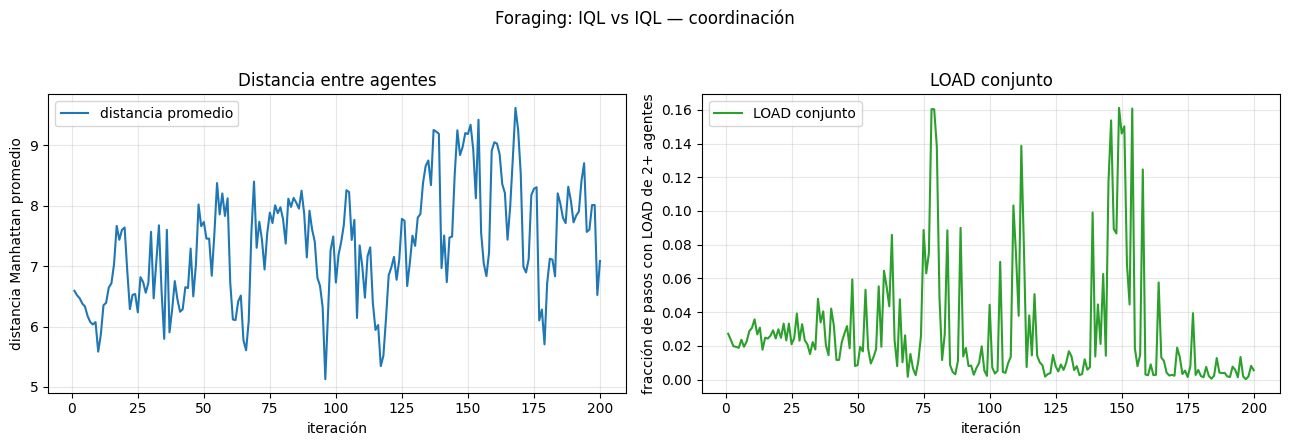

In [16]:
history_iql_iql = run_or_load_scenario('IQL vs IQL')
plot_report_figures(history_iql_iql)

## JAL-AM vs JAL-AM

Ambos agentes usan Joint Action Learning con Agent Modeling. Cada agente estima el comportamiento del otro y aprende valores sobre acciones conjuntas.


2026-05-24 10:48:49 | INFO    | JAL-AM vs JAL-AM: inicio 200 iter × 1000 episodios
2026-05-24 10:48:53 | INFO    | JAL-AM vs JAL-AM: iter 1/200 reward={'agent_0': 0.321, 'agent_1': 0.136} |Q|={'agent_0': 3070, 'agent_1': 3070}
2026-05-24 10:49:15 | INFO    | JAL-AM vs JAL-AM: iter 20/200 reward={'agent_0': 0.98, 'agent_1': 0.02} |Q|={'agent_0': 3430, 'agent_1': 3430}
2026-05-24 10:49:31 | INFO    | JAL-AM vs JAL-AM: iter 40/200 reward={'agent_0': 0.9685, 'agent_1': 0.0315} |Q|={'agent_0': 3430, 'agent_1': 3430}
2026-05-24 10:49:46 | INFO    | JAL-AM vs JAL-AM: iter 60/200 reward={'agent_0': 0.976, 'agent_1': 0.024} |Q|={'agent_0': 3430, 'agent_1': 3430}
2026-05-24 10:50:02 | INFO    | JAL-AM vs JAL-AM: iter 80/200 reward={'agent_0': 0.9675, 'agent_1': 0.0325} |Q|={'agent_0': 3430, 'agent_1': 3430}
2026-05-24 10:50:18 | INFO    | JAL-AM vs JAL-AM: iter 100/200 reward={'agent_0': 0.9665, 'agent_1': 0.0335} |Q|={'agent_0': 3430, 'agent_1': 3430}
2026-05-24 10:50:33 | INFO    | JAL-AM vs J

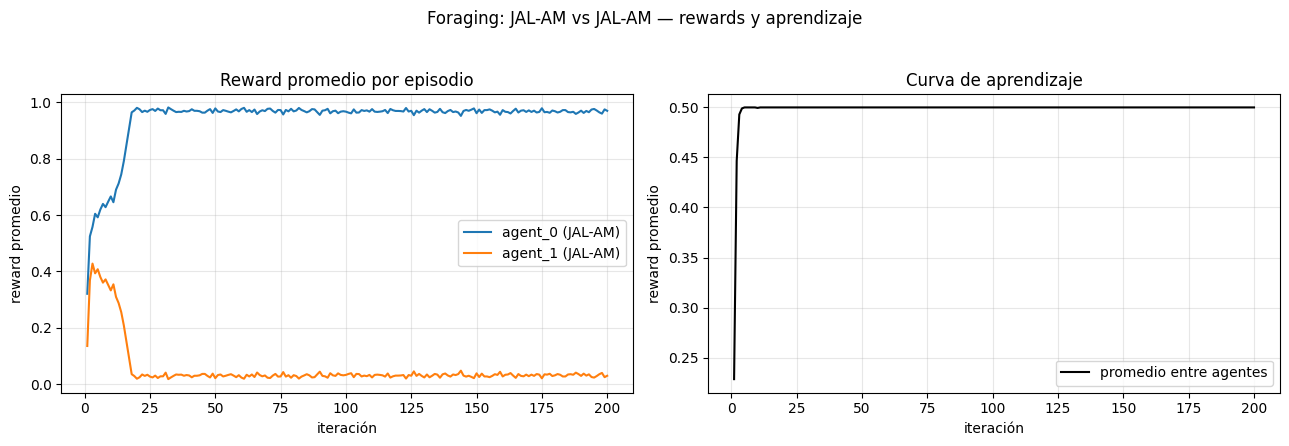

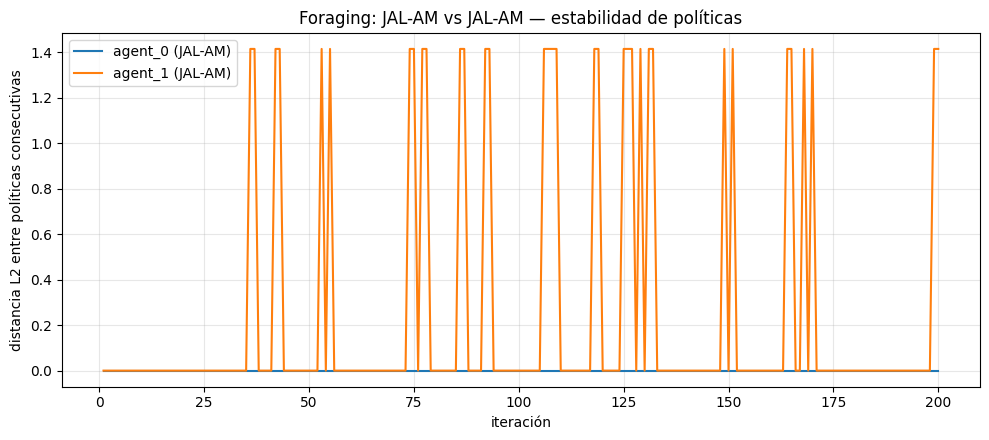

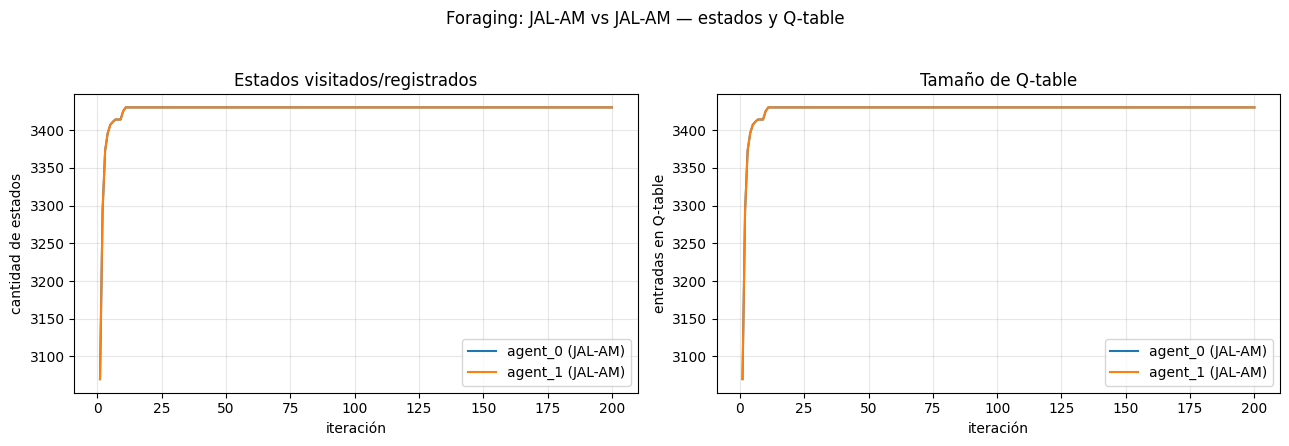

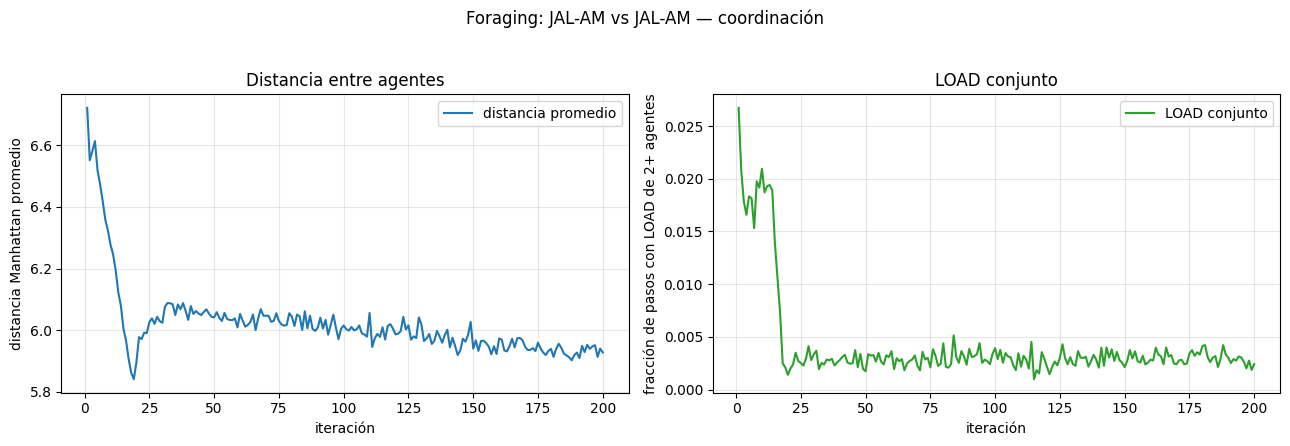

In [17]:
history_jalam_jalam = run_or_load_scenario('JAL-AM vs JAL-AM')
plot_report_figures(history_jalam_jalam)

## IQL vs JAL-AM

Este enfrentamiento compara aprendizaje independiente contra aprendizaje con modelado de acciones conjuntas. Permite observar si JAL-AM logra una ventaja práctica en coordinación o reward.


2026-05-24 10:51:38 | INFO    | IQL vs JAL-AM: inicio 200 iter × 1000 episodios
2026-05-24 10:51:42 | INFO    | IQL vs JAL-AM: iter 1/200 reward={'agent_0': 0.3135, 'agent_1': 0.1225} |Q|={'agent_0': 3068, 'agent_1': 3068}
2026-05-24 10:52:02 | INFO    | IQL vs JAL-AM: iter 20/200 reward={'agent_0': 0.979, 'agent_1': 0.02} |Q|={'agent_0': 3439, 'agent_1': 3439}
2026-05-24 10:52:16 | INFO    | IQL vs JAL-AM: iter 40/200 reward={'agent_0': 0.97, 'agent_1': 0.03} |Q|={'agent_0': 3439, 'agent_1': 3439}
2026-05-24 10:52:31 | INFO    | IQL vs JAL-AM: iter 60/200 reward={'agent_0': 0.98, 'agent_1': 0.019} |Q|={'agent_0': 3439, 'agent_1': 3439}
2026-05-24 10:52:45 | INFO    | IQL vs JAL-AM: iter 80/200 reward={'agent_0': 0.972, 'agent_1': 0.028} |Q|={'agent_0': 3439, 'agent_1': 3439}
2026-05-24 10:52:59 | INFO    | IQL vs JAL-AM: iter 100/200 reward={'agent_0': 0.9755, 'agent_1': 0.0245} |Q|={'agent_0': 3439, 'agent_1': 3439}
2026-05-24 10:53:13 | INFO    | IQL vs JAL-AM: iter 120/200 reward={

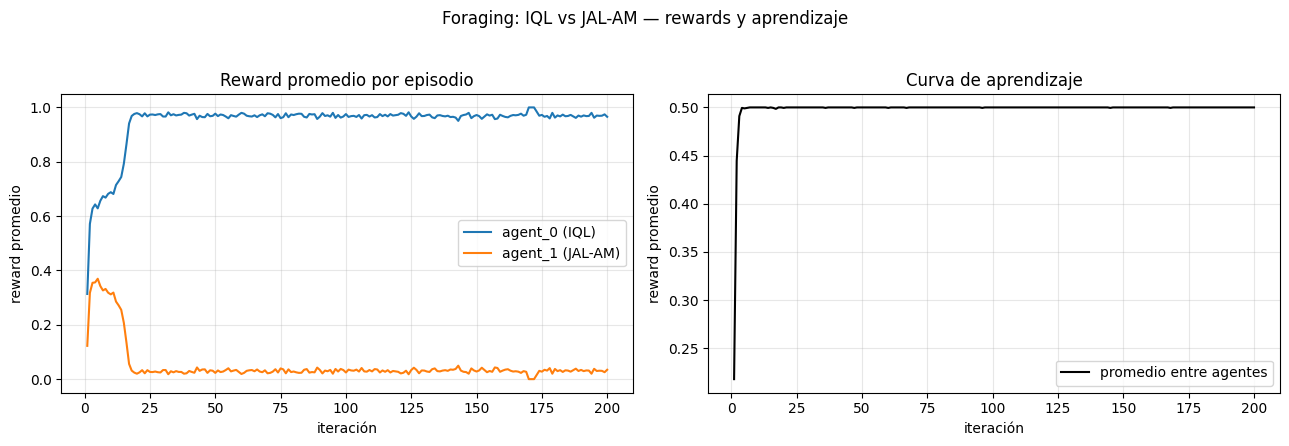

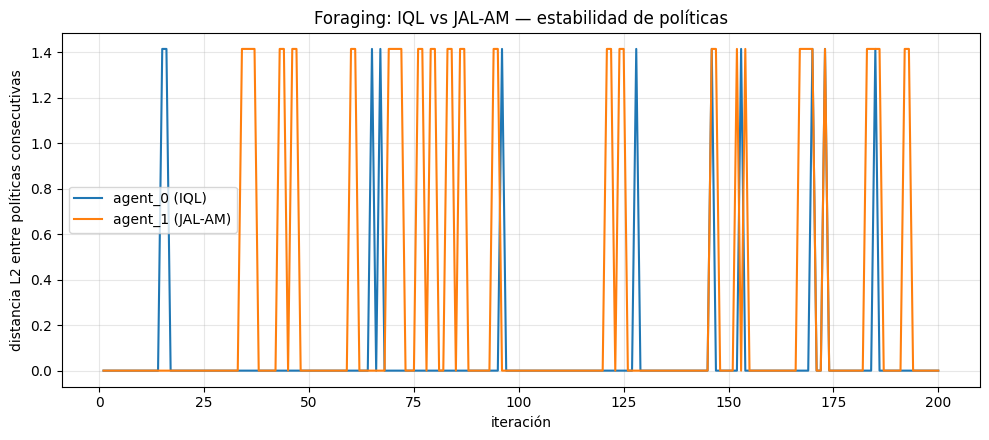

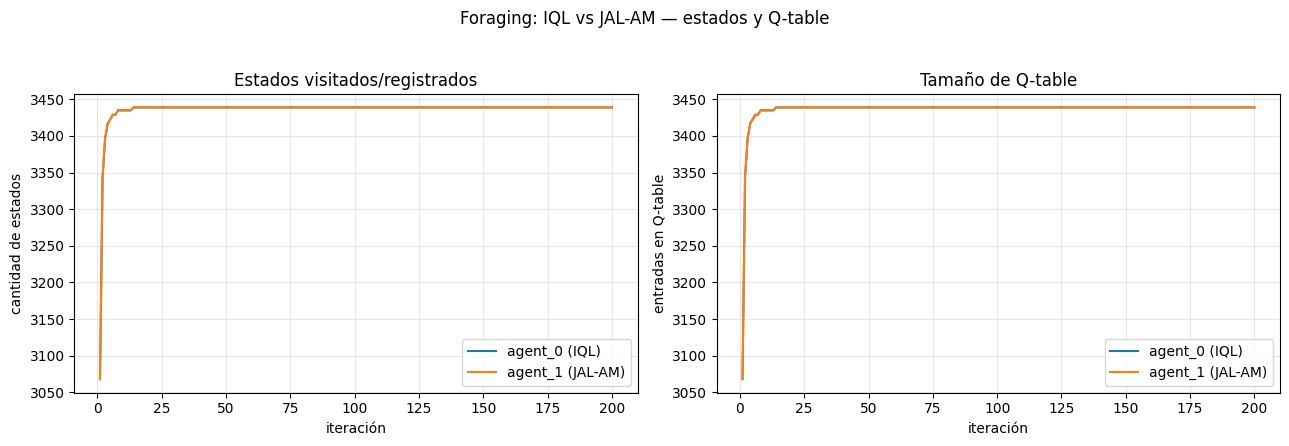

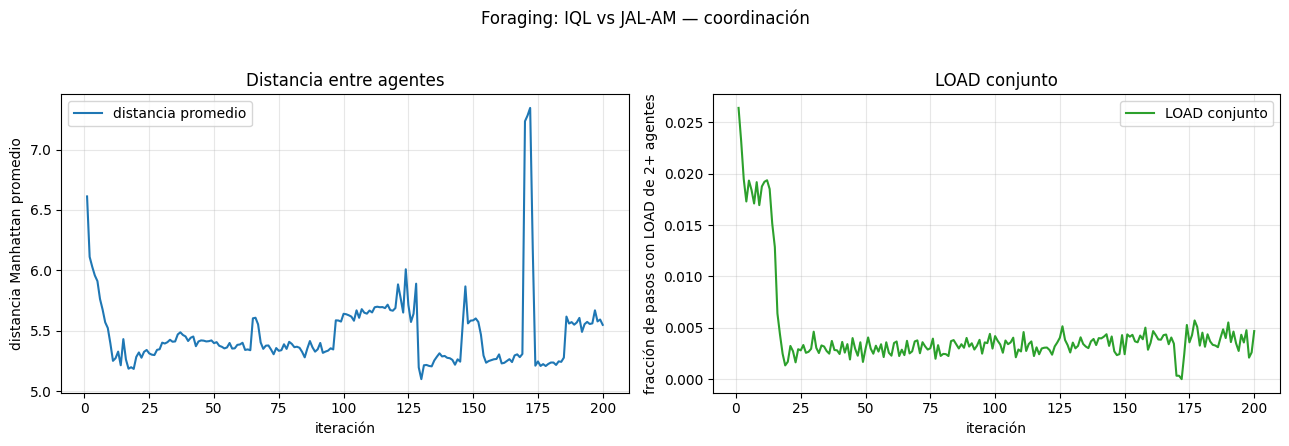

In [18]:
history_iql_jalam = run_or_load_scenario('IQL vs JAL-AM')
plot_report_figures(history_iql_jalam)

## Resumen numérico final

In [19]:
summary_rows = []
for history in [history_iql_iql, history_jalam_jalam, history_iql_jalam]:
    for agent in history['avg_rewards']:
        summary_rows.append({
            'scenario': history['scenario'],
            'agent': agent,
            'type': history['agent_types'][agent],
            'final_avg_reward': history['avg_rewards'][agent][-1],
            'final_policy_delta': history['policy_delta'][agent][-1],
            'final_q_table_size': history['q_table_size'][agent][-1],
            'final_visited_states': history['visited_states'][agent][-1],
            'final_pairwise_distance': history['avg_pairwise_distance'][-1],
            'final_joint_load_rate': history['joint_load_rate'][-1],
            'final_avg_steps': history['avg_steps'][-1],
        })

summary = pd.DataFrame(summary_rows)
summary

,scenario,agent,type,final_avg_reward,final_policy_delta,final_q_table_size,final_visited_states,final_pairwise_distance,final_joint_load_rate,final_avg_steps
0,IQL vs IQL,agent_0,IQL,0.9950,0.000000,3367,3367,7.085839,0.005601,6.064
1,IQL vs IQL,agent_1,IQL,0.0050,1.414214,3367,3367,7.085839,0.005601,6.064
2,JAL-AM vs JAL-AM,agent_0,JAL-AM,0.9695,0.000000,3430,3430,5.927738,0.002411,6.044
3,JAL-AM vs JAL-AM,agent_1,JAL-AM,0.0305,1.414214,3430,3430,5.927738,0.002411,6.044
4,IQL vs JAL-AM,agent_0,IQL,0.9655,0.000000,3439,3439,5.549250,0.004679,6.051
5,IQL vs JAL-AM,agent_1,JAL-AM,0.0345,0.000000,3439,3439,5.549250,0.004679,6.051


## Render opcional de una política entrenada

Ejecutar esta celda solo si se quiere visualizar un episodio después del entrenamiento. Cambiar `scenario_to_render` para elegir la competencia.


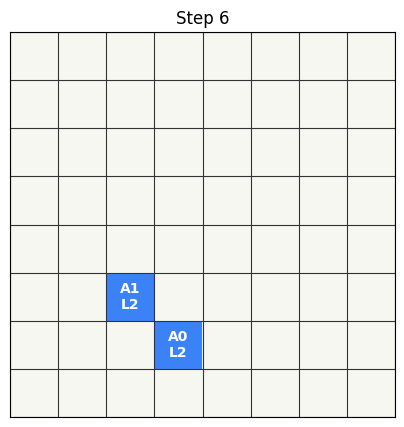

{'rewards': {'agent_0': 1.0, 'agent_1': 0.0},
 'avg_pairwise_distance': 5.5,
 'joint_load_rate': 0.0,
 'steps': 6}

In [20]:
scenario_to_render = 'IQL vs JAL-AM'
slug = scenario_slug(scenario_to_render)
game = make_game(SEED)
agents = load_agents(f'foraging_{slug}', game=game, game_folder='foraging')
for agent in agents.values():
    agent.learn = False

play_episode(game, agents, render=True)

---

**Notas**:

- Los historiales quedan persistidos en `data/foraging/foraging_history_*.pkl`.
- Los agentes entrenados quedan persistidos en `data/foraging/agents_foraging_*.pkl`.
- Las figuras se guardan en `images/foraging/*.png`.
- El progreso del experimento queda en `logs/foraging/Foraging2.log`.


## Baselines con RandomAgent

Se agregan dos comparaciones contra un agente aleatorio en el entorno de dos agentes: **IQL vs Random** y **JAL-AM vs Random**. Random funciona como baseline porque no aprende ni adapta su política; por lo tanto permite observar si IQL y JAL-AM efectivamente aprovechan el entrenamiento para superar una conducta uniforme.


In [57]:
from agents.random_agent import RandomAgent


class SequentialRandomAgent(RandomAgent):
    def __init__(self, game, agent, config=None, seed=None):
        super().__init__(game=game, agent=agent, seed=seed)
        self.learn = False

    def reset(self):
        pass

    def update(self):
        pass


RANDOM_SCENARIOS = {
    'IQL vs Random': [(IQLAgent, IQL_CONFIG), (SequentialRandomAgent, None)],
    'JAL-AM vs Random': [(JALAMAgent, JALAM_CONFIG), (SequentialRandomAgent, None)],
}
RANDOM_FORCE_RUN = True

log.info('Setup Foraging baselines Random listo')

2026-05-24 18:52:23 | INFO    | Setup Foraging baselines Random listo


### Helpers para baselines Random

In [58]:
def make_random_baseline_agents(game, scenario_name, seed=SEED):
    specs = RANDOM_SCENARIOS[scenario_name]
    agents = {}
    for idx, agent_name in enumerate(game.agents):
        AgentClass, base_config = specs[idx]
        if base_config is None:
            agents[agent_name] = AgentClass(game=game, agent=agent_name, seed=seed + idx)
        else:
            cfg = replace(base_config, seed=seed + idx)
            agents[agent_name] = AgentClass(game=game, agent=agent_name, config=cfg)
    return agents


def train_random_baseline_scenario(scenario_name, seed=SEED, episodes_per_iter=EPISODES_PER_ITER, iterations=ITERATIONS):
    game = make_game(seed)
    agents = make_random_baseline_agents(game, scenario_name, seed)
    slug = scenario_slug(scenario_name)

    history = {
        'scenario': scenario_name,
        'game_name': GAME_NAME,
        'seed': seed,
        'episodes_per_iter': episodes_per_iter,
        'iterations': iterations,
        'max_episode_steps': MAX_EPISODE_STEPS,
        'agent_types': {agent: ('Random' if isinstance(agents[agent], SequentialRandomAgent) else agent_kind(agents[agent])) for agent in game.agents},
        'avg_rewards': {agent: [] for agent in game.agents},
        'mean_reward': [],
        'policy_delta': {agent: [] for agent in game.agents},
        'q_table_size': {agent: [] for agent in game.agents},
        'visited_states': {agent: [] for agent in game.agents},
        'avg_pairwise_distance': [],
        'joint_load_rate': [],
        'avg_steps': [],
    }

    log.info(f'{scenario_name}: inicio {iterations} iter × {episodes_per_iter} episodios')
    previous_policy = None
    log_every = max(1, iterations // 10)

    for iteration in range(1, iterations + 1):
        iteration_metrics = run_iteration(game, agents, episodes_per_iter)

        for agent in game.agents:
            history['avg_rewards'][agent].append(iteration_metrics['avg_rewards'][agent])
            size = q_table_size(agents[agent])
            history['q_table_size'][agent].append(size)
            history['visited_states'][agent].append(size)

        history['mean_reward'].append(float(np.mean(list(iteration_metrics['avg_rewards'].values()))))
        history['avg_pairwise_distance'].append(iteration_metrics['avg_pairwise_distance'])
        history['joint_load_rate'].append(iteration_metrics['joint_load_rate'])
        history['avg_steps'].append(iteration_metrics['avg_steps'])

        current_policy = policy_snapshot(game, agents)
        deltas = policy_delta(previous_policy, current_policy)
        previous_policy = current_policy
        for agent in game.agents:
            history['policy_delta'][agent].append(deltas[agent])

        if iteration == 1 or iteration % log_every == 0 or iteration == iterations:
            reward_msg = {a: round(history['avg_rewards'][a][-1], 4) for a in game.agents}
            q_msg = {a: history['q_table_size'][a][-1] for a in game.agents}
            log.info(f'{scenario_name}: iter {iteration}/{iterations} reward={reward_msg} |Q|={q_msg}')

    for agent in game.agents:
        agents[agent].learn = False

    exp.save_agents(agents, name=f'foraging_{slug}', game='foraging')
    log.info(f'{scenario_name}: agentes guardados como foraging_{slug}')
    return history


def run_or_load_random_baseline_scenario(scenario_name):
    slug = scenario_slug(scenario_name)
    cache_name = f'foraging_history_{slug}'
    return exp.cached(
        cache_name,
        lambda: train_random_baseline_scenario(scenario_name),
        force=RANDOM_FORCE_RUN,
        game='foraging',
    )

## IQL vs Random

El agente IQL aprende contra un oponente aleatorio uniforme. Si el aprendizaje resulta efectivo, debería obtener más reward que el baseline random y mostrar una Q-table creciente.


2026-05-24 18:52:52 | INFO    | IQL vs Random: inicio 200 iter × 1000 episodios
2026-05-24 18:52:56 | INFO    | IQL vs Random: iter 1/200 reward={'agent_0': 0.3285, 'agent_1': 0.0745} |Q|={'agent_0': 3068, 'agent_1': 0}
2026-05-24 18:53:15 | INFO    | IQL vs Random: iter 20/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3444, 'agent_1': 0}
2026-05-24 18:53:27 | INFO    | IQL vs Random: iter 40/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3444, 'agent_1': 0}
2026-05-24 18:53:40 | INFO    | IQL vs Random: iter 60/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3444, 'agent_1': 0}
2026-05-24 18:53:53 | INFO    | IQL vs Random: iter 80/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3444, 'agent_1': 0}
2026-05-24 18:54:05 | INFO    | IQL vs Random: iter 100/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3444, 'agent_1': 0}
2026-05-24 18:54:18 | INFO    | IQL vs Random: iter 120/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|=

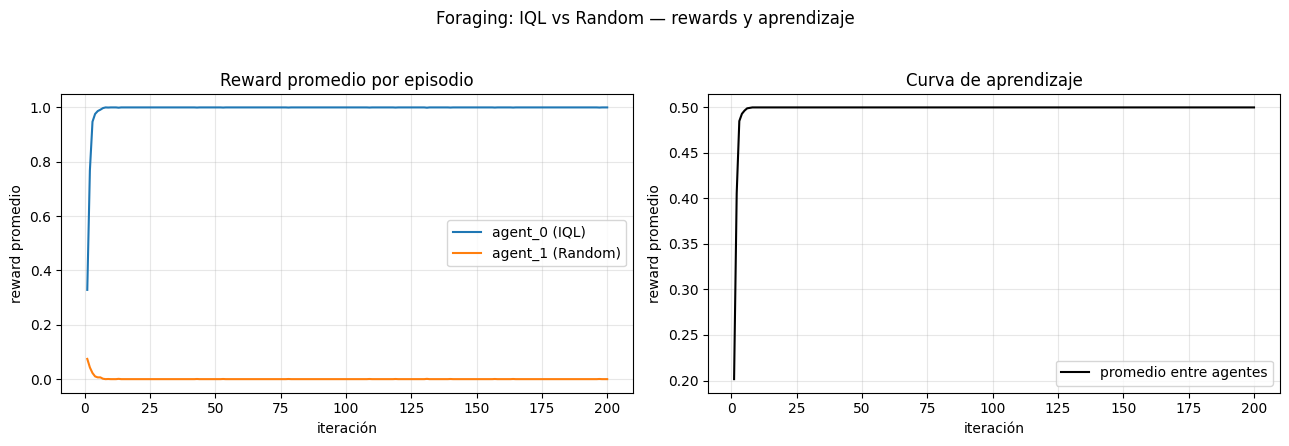

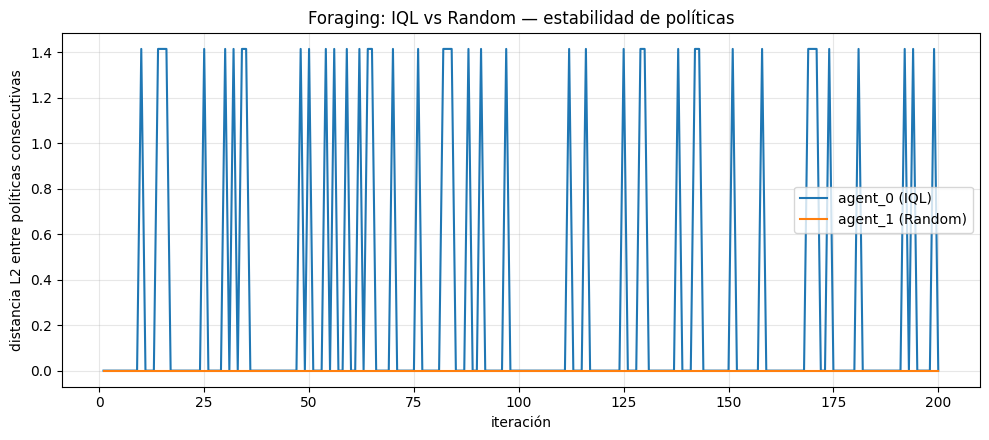

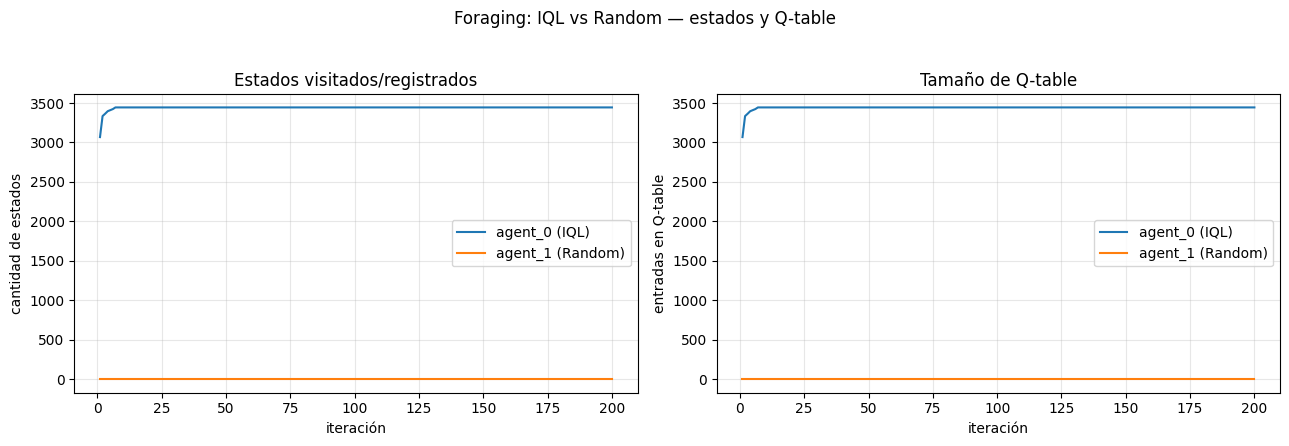

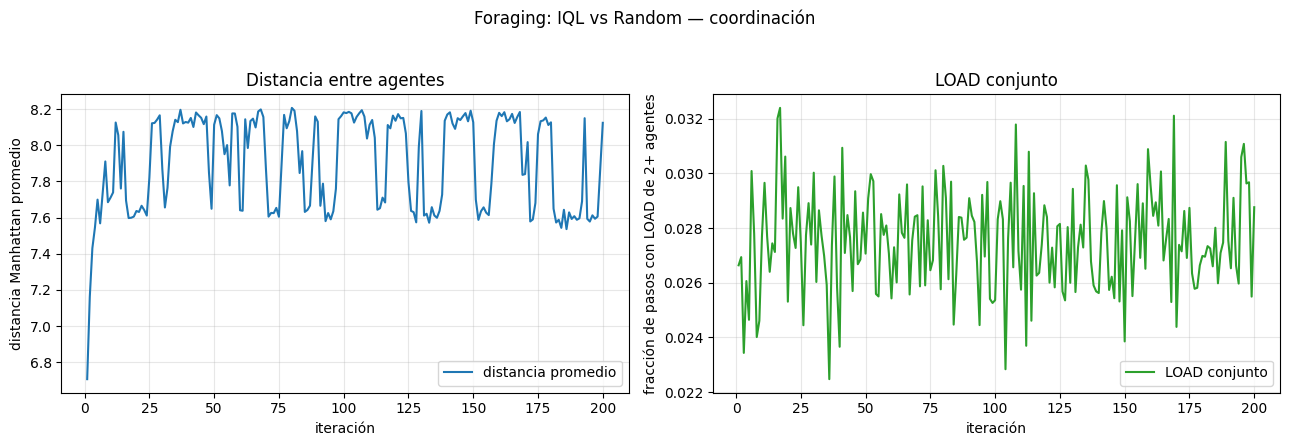

In [59]:
history_iql_random = run_or_load_random_baseline_scenario('IQL vs Random')
plot_report_figures(history_iql_random)

## JAL-AM vs Random

El agente JAL-AM aprende contra un oponente aleatorio uniforme. Esta comparación permite observar si el modelado de acciones conjuntas aporta ventaja frente a un agente que no aprende.


2026-05-24 18:56:39 | INFO    | JAL-AM vs Random: inicio 200 iter × 1000 episodios
2026-05-24 18:56:44 | INFO    | JAL-AM vs Random: iter 1/200 reward={'agent_0': 0.3395, 'agent_1': 0.0825} |Q|={'agent_0': 3017, 'agent_1': 0}
2026-05-24 18:57:06 | INFO    | JAL-AM vs Random: iter 20/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3394, 'agent_1': 0}
2026-05-24 18:57:21 | INFO    | JAL-AM vs Random: iter 40/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3394, 'agent_1': 0}
2026-05-24 18:57:36 | INFO    | JAL-AM vs Random: iter 60/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3394, 'agent_1': 0}
2026-05-24 18:57:51 | INFO    | JAL-AM vs Random: iter 80/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3394, 'agent_1': 0}
2026-05-24 18:58:06 | INFO    | JAL-AM vs Random: iter 100/200 reward={'agent_0': 1.0, 'agent_1': 0.0} |Q|={'agent_0': 3394, 'agent_1': 0}
2026-05-24 18:58:21 | INFO    | JAL-AM vs Random: iter 120/200 reward={'agent_0': 1

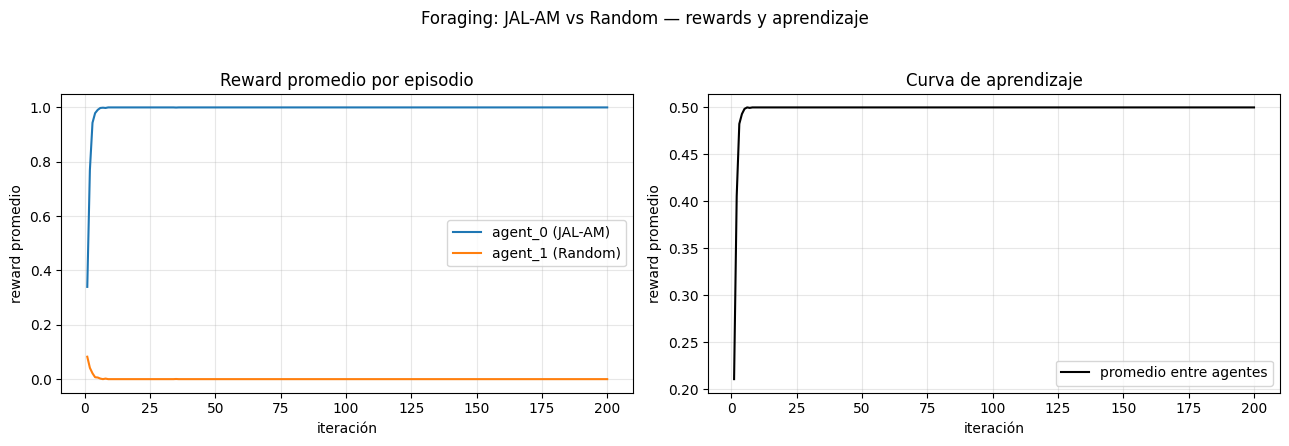

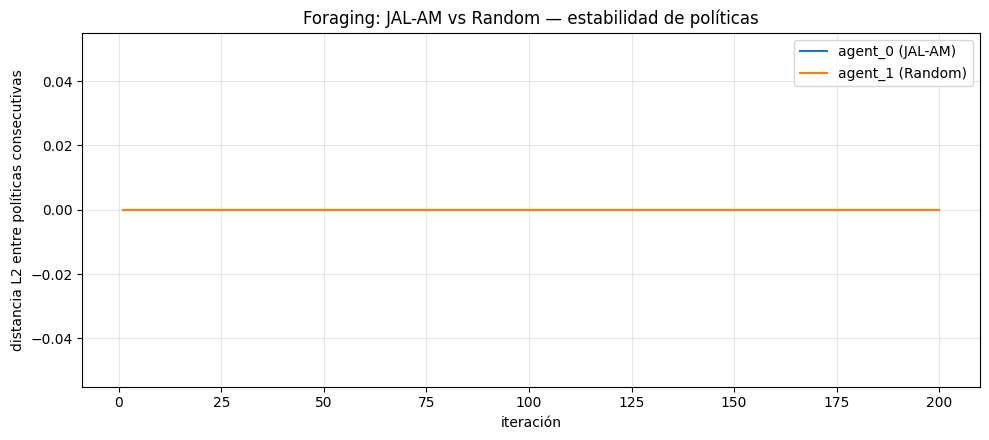

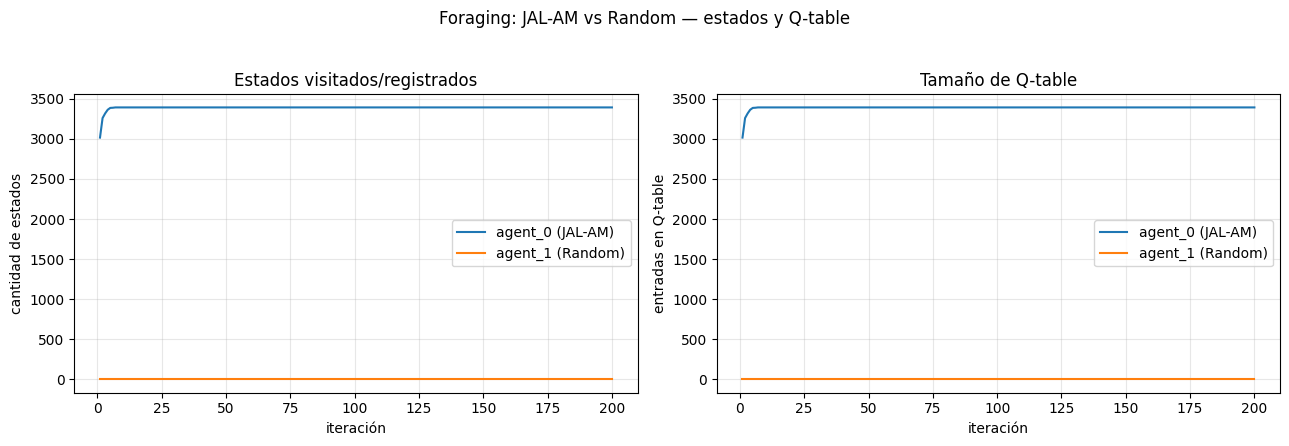

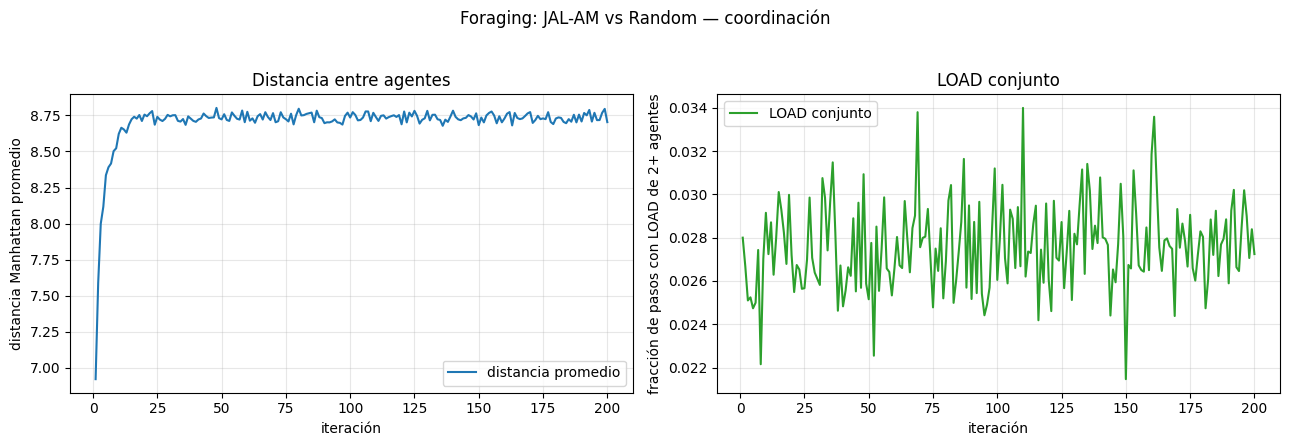

In [60]:
history_jalam_random = run_or_load_random_baseline_scenario('JAL-AM vs Random')
plot_report_figures(history_jalam_random)

## Resumen baselines Random

In [61]:
random_summary_rows = []
for history in [history_iql_random, history_jalam_random]:
    for agent in history['avg_rewards']:
        random_summary_rows.append({
            'scenario': history['scenario'],
            'agent': agent,
            'type': history['agent_types'][agent],
            'final_avg_reward': history['avg_rewards'][agent][-1],
            'final_policy_delta': history['policy_delta'][agent][-1],
            'final_q_table_size': history['q_table_size'][agent][-1],
            'final_visited_states': history['visited_states'][agent][-1],
            'final_pairwise_distance': history['avg_pairwise_distance'][-1],
            'final_joint_load_rate': history['joint_load_rate'][-1],
            'final_avg_steps': history['avg_steps'][-1],
        })

random_summary = pd.DataFrame(random_summary_rows)
random_summary

,scenario,agent,type,final_avg_reward,final_policy_delta,final_q_table_size,final_visited_states,final_pairwise_distance,final_joint_load_rate,final_avg_steps
0,IQL vs Random,agent_0,IQL,1.0,0.0,3444,3444,8.124443,0.028762,6.082
1,IQL vs Random,agent_1,Random,0.0,0.0,0,0,8.124443,0.028762,6.082
2,JAL-AM vs Random,agent_0,JAL-AM,1.0,0.0,3394,3394,8.703315,0.027242,6.093
3,JAL-AM vs Random,agent_1,Random,0.0,0.0,0,0,8.703315,0.027242,6.093


## Experimento adicional: Foraging cooperativo 3 agentes

Este bloque agrega una corrida independiente sobre `Foraging-8x8-3p-1f-coop-v3`. No modifica los experimentos anteriores ni sus figuras. La variante usa dos agentes JAL-AM y un agente IQL para observar cómo interactúa el modelado de acciones conjuntas con un aprendiz independiente dentro de un entorno cooperativo de tres agentes.


In [44]:
COOP_GAME_NAME = 'Foraging-8x8-3p-1f-coop-v3'
COOP_SCENARIO = 'Coop 3P 2JAL-AM 1IQL'
COOP_SEED = 1
COOP_MAX_EPISODE_STEPS = 200
COOP_EPISODES_PER_ITER = 1000
COOP_ITERATIONS = 200
COOP_FORCE_RUN = True

COOP_AGENT_SPECS = [
    (JALAMAgent, JALAM_CONFIG),
    (JALAMAgent, JALAM_CONFIG),
    (IQLAgent, IQL_CONFIG),
]

log.info('Setup Foraging cooperativo 3P listo: 2 JAL-AM + 1 IQL')

2026-05-24 17:14:09 | INFO    | Setup Foraging cooperativo 3P listo: 2 JAL-AM + 1 IQL


### Helpers específicos del caso cooperativo

Se reutilizan `play_episode`, `run_iteration`, `plot_report_figures` y los helpers de métricas definidos antes. Estos wrappers solo cambian el entorno, la cantidad de agentes y el nombre de cache/figuras para no pisar los resultados anteriores.


In [45]:
def make_coop_game(seed=COOP_SEED):
    return Foraging(
        config=COOP_GAME_NAME,
        seed=seed,
        max_episode_steps=COOP_MAX_EPISODE_STEPS,
    )


def make_coop_agents(game, seed=COOP_SEED):
    if len(COOP_AGENT_SPECS) != len(game.agents):
        raise ValueError(f'COOP_AGENT_SPECS tiene {len(COOP_AGENT_SPECS)} agentes, pero el juego tiene {len(game.agents)}')
    agents = {}
    for idx, agent_name in enumerate(game.agents):
        AgentClass, base_config = COOP_AGENT_SPECS[idx]
        cfg = replace(base_config, seed=seed + idx)
        agents[agent_name] = AgentClass(game=game, agent=agent_name, config=cfg)
    return agents


def train_coop_scenario(seed=COOP_SEED, episodes_per_iter=COOP_EPISODES_PER_ITER, iterations=COOP_ITERATIONS):
    game = make_coop_game(seed)
    agents = make_coop_agents(game, seed)

    history = {
        'scenario': COOP_SCENARIO,
        'game_name': COOP_GAME_NAME,
        'seed': seed,
        'episodes_per_iter': episodes_per_iter,
        'iterations': iterations,
        'max_episode_steps': COOP_MAX_EPISODE_STEPS,
        'agent_types': {agent: agent_kind(agents[agent]) for agent in game.agents},
        'avg_rewards': {agent: [] for agent in game.agents},
        'mean_reward': [],
        'policy_delta': {agent: [] for agent in game.agents},
        'q_table_size': {agent: [] for agent in game.agents},
        'visited_states': {agent: [] for agent in game.agents},
        'avg_pairwise_distance': [],
        'joint_load_rate': [],
        'avg_steps': [],
    }

    log.info(f'{COOP_SCENARIO}: inicio {iterations} iter × {episodes_per_iter} episodios')
    previous_policy = None
    log_every = max(1, iterations // 10)

    for iteration in range(1, iterations + 1):
        iteration_metrics = run_iteration(game, agents, episodes_per_iter)

        for agent in game.agents:
            history['avg_rewards'][agent].append(iteration_metrics['avg_rewards'][agent])
            size = q_table_size(agents[agent])
            history['q_table_size'][agent].append(size)
            history['visited_states'][agent].append(size)

        history['mean_reward'].append(float(np.mean(list(iteration_metrics['avg_rewards'].values()))))
        history['avg_pairwise_distance'].append(iteration_metrics['avg_pairwise_distance'])
        history['joint_load_rate'].append(iteration_metrics['joint_load_rate'])
        history['avg_steps'].append(iteration_metrics['avg_steps'])

        current_policy = policy_snapshot(game, agents)
        deltas = policy_delta(previous_policy, current_policy)
        previous_policy = current_policy
        for agent in game.agents:
            history['policy_delta'][agent].append(deltas[agent])

        if iteration == 1 or iteration % log_every == 0 or iteration == iterations:
            reward_msg = {a: round(history['avg_rewards'][a][-1], 4) for a in game.agents}
            q_msg = {a: history['q_table_size'][a][-1] for a in game.agents}
            log.info(f'{COOP_SCENARIO}: iter {iteration}/{iterations} reward={reward_msg} |Q|={q_msg}')

    for agent in game.agents:
        agents[agent].learn = False

    slug = scenario_slug(COOP_SCENARIO)
    exp.save_agents(agents, name=f'foraging_{slug}', game='foraging')
    log.info(f'{COOP_SCENARIO}: agentes guardados como foraging_{slug}')
    return history


def run_or_load_coop_scenario():
    slug = scenario_slug(COOP_SCENARIO)
    cache_name = f'foraging_history_{slug}'
    return exp.cached(
        cache_name,
        train_coop_scenario,
        force=COOP_FORCE_RUN,
        game='foraging',
    )

### Ejecutar cooperativo 3P y guardar figuras

Ejecutar esta celda cuando se quiera generar el experimento nuevo. Las imágenes quedan en `images/foraging/` con prefijo `coop_3p_2jal_am_1iql_*`.


2026-05-24 17:14:09 | INFO    | Coop 3P 2JAL-AM 1IQL: inicio 200 iter × 1000 episodios
2026-05-24 17:14:17 | INFO    | Coop 3P 2JAL-AM 1IQL: iter 1/200 reward={'agent_0': 0.0, 'agent_1': 0.0, 'agent_2': 0.0} |Q|={'agent_0': 24658, 'agent_1': 24658, 'agent_2': 24658}
2026-05-24 17:17:20 | INFO    | Coop 3P 2JAL-AM 1IQL: iter 20/200 reward={'agent_0': 0.0, 'agent_1': 0.0, 'agent_2': 0.0} |Q|={'agent_0': 132644, 'agent_1': 132644, 'agent_2': 132644}
2026-05-24 17:20:09 | INFO    | Coop 3P 2JAL-AM 1IQL: iter 40/200 reward={'agent_0': 0.4915, 'agent_1': 0.2457, 'agent_2': 0.2457} |Q|={'agent_0': 161381, 'agent_1': 161381, 'agent_2': 161381}
2026-05-24 17:21:02 | INFO    | Coop 3P 2JAL-AM 1IQL: iter 60/200 reward={'agent_0': 0.4995, 'agent_1': 0.2497, 'agent_2': 0.2497} |Q|={'agent_0': 161478, 'agent_1': 161478, 'agent_2': 161478}
2026-05-24 17:21:55 | INFO    | Coop 3P 2JAL-AM 1IQL: iter 80/200 reward={'agent_0': 0.4985, 'agent_1': 0.2492, 'agent_2': 0.2492} |Q|={'agent_0': 161515, 'agent_1

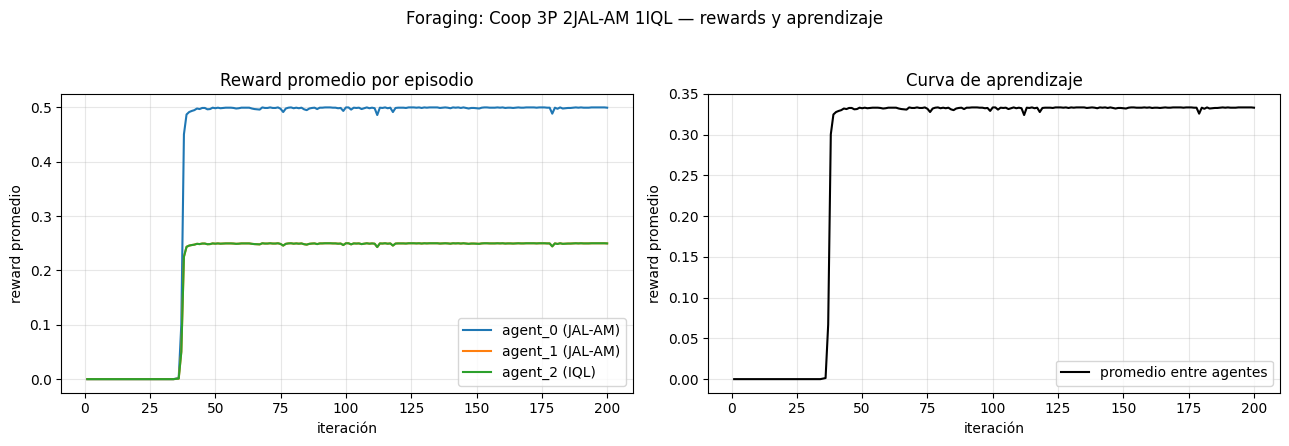

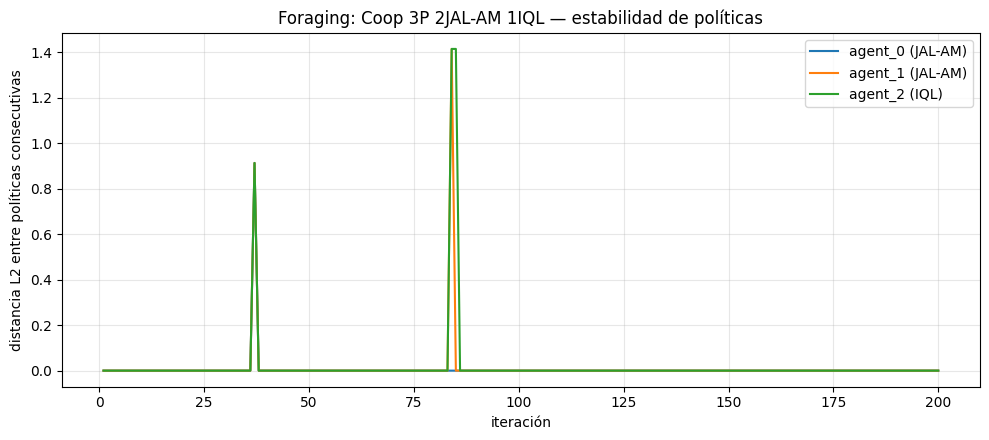

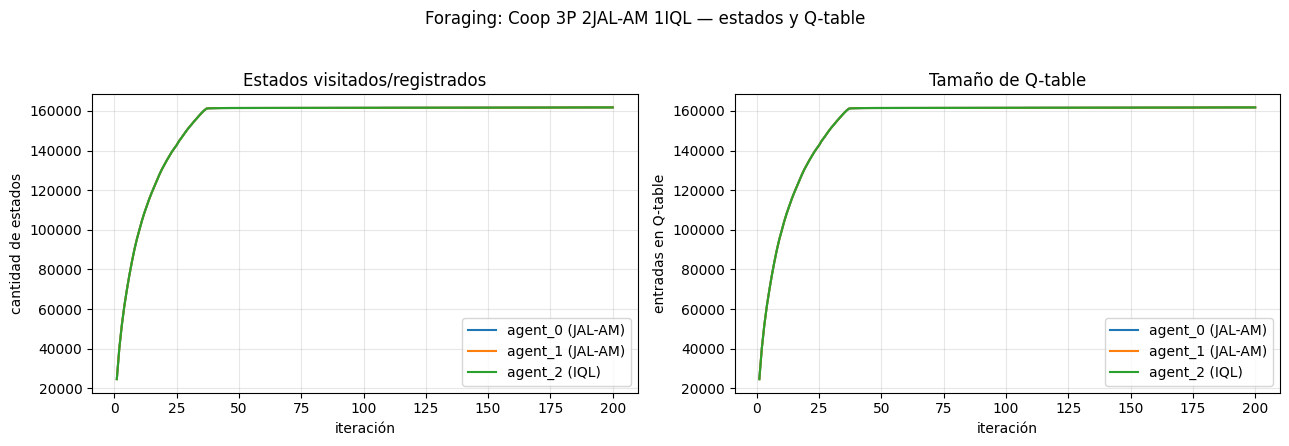

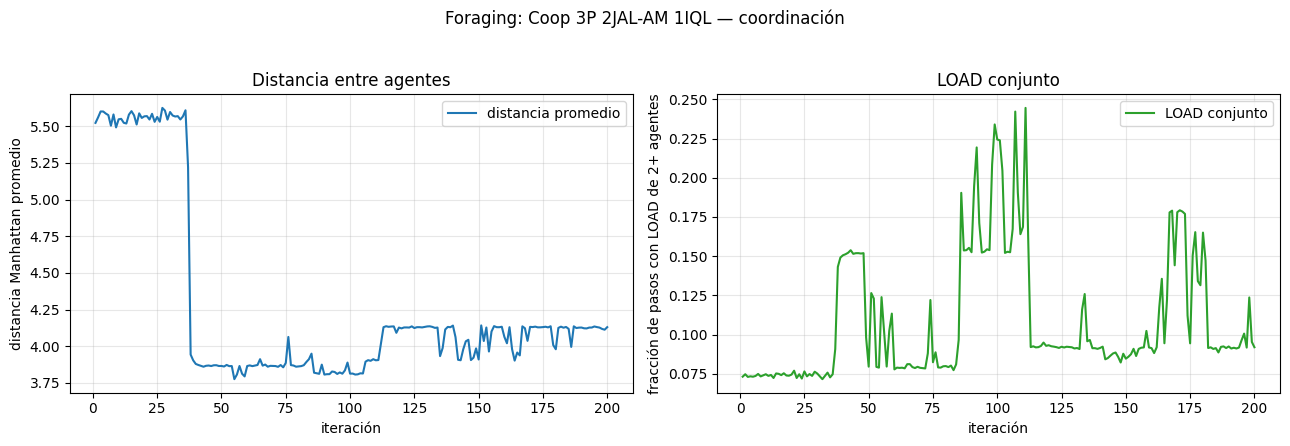

In [46]:
history_coop_3p_jalam = run_or_load_coop_scenario()
plot_report_figures(history_coop_3p_jalam)

### Resumen cooperativo 3P

In [49]:
coop_summary_rows = []
for agent in history_coop_3p_jalam['avg_rewards']:
    coop_summary_rows.append({
        'scenario': history_coop_3p_jalam['scenario'],
        'agent': agent,
        'type': history_coop_3p_jalam['agent_types'][agent],
        'final_avg_reward': history_coop_3p_jalam['avg_rewards'][agent][-1],
        'final_policy_delta': history_coop_3p_jalam['policy_delta'][agent][-1],
        'final_q_table_size': history_coop_3p_jalam['q_table_size'][agent][-1],
        'final_visited_states': history_coop_3p_jalam['visited_states'][agent][-1],
        'final_pairwise_distance': history_coop_3p_jalam['avg_pairwise_distance'][-1],
        'final_joint_load_rate': history_coop_3p_jalam['joint_load_rate'][-1],
        'final_avg_steps': history_coop_3p_jalam['avg_steps'][-1],
    })

coop_summary = pd.DataFrame(coop_summary_rows)
coop_summary

,scenario,agent,type,final_avg_reward,final_policy_delta,final_q_table_size,final_visited_states,final_pairwise_distance,final_joint_load_rate,final_avg_steps
0,Coop 3P 2JAL-AM 1IQL,agent_0,JAL-AM,0.49950,0.0,161747,161747,4.130555,0.09197,11.547
1,Coop 3P 2JAL-AM 1IQL,agent_1,JAL-AM,0.24975,0.0,161747,161747,4.130555,0.09197,11.547
2,Coop 3P 2JAL-AM 1IQL,agent_2,IQL,0.24975,0.0,161747,161747,4.130555,0.09197,11.547


### Render opcional cooperativo 3P

Ejecutar esta celda solo después de entrenar el experimento cooperativo. Carga los tres agentes guardados y muestra un episodio con `render=True`.


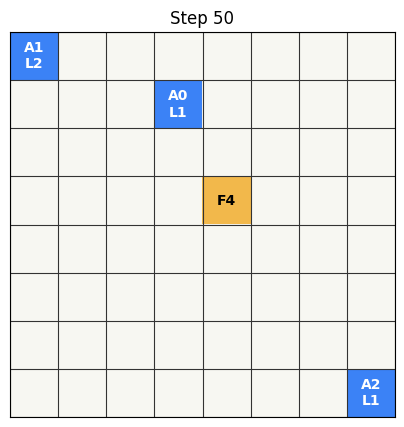

{'rewards': {'agent_0': 0.0, 'agent_1': 0.0, 'agent_2': 0.0},
 'avg_pairwise_distance': 5.453333333333334,
 'joint_load_rate': 0.06,
 'steps': 50}

In [ ]:
coop_slug = scenario_slug(COOP_SCENARIO)
coop_game = make_coop_game(COOP_SEED)
# coop_game = make_coop_game(seed=8)
coop_agents = load_agents(f'foraging_{coop_slug}', game=coop_game, game_folder='foraging')
for agent in coop_agents.values():
    agent.learn = False

play_episode(coop_game, coop_agents, render=True)

---

**Notas**:

- Los `history` dicts y los agentes entrenados quedan persistidos en `data/foraging/*.pkl`. Re-entrenar es costoso (~minutos por enfrentamiento), así que el notebook usa `run_or_load_scenario` para reutilizar lo cacheado por defecto.
- Las figuras se guardan en `images/foraging/*.png`.
- El progreso del entrenamiento queda en `logs/foraging/Foraging.log`.